# 3 · Demo: when plain covers provably fail (cospectral SRGs)

In notebook 02 a humble component count tied the reachability cover. To make the
Grothendieck machinery load-bearing, we need a task where walk- and
reachability-based features are blind by construction.

Enter the 4×4 Rook's graph vs. the Shrikhande graph: both are
$\mathrm{SRG}(16,6,2,2)$, 16 nodes, 6-regular, every adjacent pair shares 2
common neighbors, every non-adjacent pair shares 2. They are non-isomorphic,
1-WL-indistinguishable, and cospectral. Cospectral means every walk and
closed-walk count is identical at every length, so any model built on the walk or
reachability cover is at chance. Only the sieve cover separates them. This
reproduces `run_sieve.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # repo root, so `import src...` works
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=2, suppress=True)
plt.rcParams["figure.figsize"] = (7, 4)

## 3.1 · Two graphs that agree on everything spectral

In [2]:
from src.srg_data import rook44, shrikhande

R, S = rook44(), shrikhande()
print("Rook:      16 nodes, degrees =", set(R.sum(1).astype(int)))
print("Shrikhande:16 nodes, degrees =", set(S.sum(1).astype(int)))

specR = np.round(np.linalg.eigvalsh(R), 3); specS = np.round(np.linalg.eigvalsh(S), 3)
print("\nspectrum (Rook):      ", sorted(set(specR.tolist())))
print("spectrum (Shrikhande):", sorted(set(specS.tolist())), " -> identical (cospectral)")

cwt = lambda A: [int(round(np.trace(np.linalg.matrix_power(A, t)))) for t in range(1, 6)]
print("\nclosed walks Tr(A^t), t=1..5:")
print("  Rook:      ", cwt(R))
print("  Shrikhande:", cwt(S), " -> identical at every length")

Rook:      16 nodes, degrees = {6}
Shrikhande:16 nodes, degrees = {6}

spectrum (Rook):       [-2.0, 2.0, 6.0]
spectrum (Shrikhande): [-2.0, 2.0, 6.0]  -> identical (cospectral)

closed walks Tr(A^t), t=1..5:
  Rook:       [0, 96, 192, 1536, 7680]
  Shrikhande: [0, 96, 192, 1536, 7680]  -> identical at every length


## 3.2 · The walk cover is blind; the sieve cover is not

Because the graphs are cospectral and vertex-transitive, the walk cover
produces the same multiset of per-node features for both. There is nothing in
the walk/closed-walk counts to separate them.

The sieve cover looks instead at the subgraph induced on each node's
neighborhood (section 1.5). For these two graphs that local structure differs:
Rook neighborhoods are two triangles, Shrikhande's are a single 6-cycle,
the same $C_6$ vs. $2\cdot C_3$ motif from notebook 1, now a local invariant.

In [3]:
from src.covers import walk_cover, sieve_cover

wR, wS = walk_cover(R, 6), walk_cover(S, 6)
print("walk-cover node-feature multisets identical (Rook vs Shrikhande)? ",
      np.array_equal(np.sort(wR, 0), np.sort(wS, 0)))

print("\nsieve cover — #triangles inside each node's neighborhood:")
print("  Rook:      ", set(sieve_cover(R, 6)[:, 0].astype(int)), " (two triangles)")
print("  Shrikhande:", set(sieve_cover(S, 6)[:, 0].astype(int)), " (one 6-cycle, no triangles)")

walk-cover node-feature multisets identical (Rook vs Shrikhande)?  True

sieve cover — #triangles inside each node's neighborhood:
  Rook:       {2}  (two triangles)
  Shrikhande: {0}  (one 6-cycle, no triangles)


## 3.3 · Same architecture, different cover basis

`CoverCombiner` is one architecture with learnable per-cover gates. It
"designs its operator" by weighting whichever covers are in its basis. We compare:

* WalkCoverNet: basis = {walk, reachability}
* SieveNet: basis = {walk, reachability, sieve}

Any gap is attributable only to adding the sieve cover.

In [4]:
import torch
from src.srg_data import make_dataset
from src.covers import reachability_cover
from src.sieve_models import CoverCombiner
from sklearn.linear_model import LogisticRegression

K, L, HIDDEN, EPOCHS = 6, 6, 32, 80

def blocks(A):
    return [walk_cover(A, K), reachability_cover(A, K), sieve_cover(A, L)]

As, y = make_dataset(n_per_class=300, seed=0)
rng = np.random.default_rng(0); order = rng.permutation(len(y))
cut = int(0.7 * len(y)); tr, te = order[:cut], order[cut:]

raw = [blocks(A) for A in As]
stats = []                                   # standardize each block on train nodes
for bi in range(3):
    rows = np.concatenate([raw[i][bi] for i in tr], 0)
    stats.append((rows.mean(0), rows.std(0) + 1e-6))
items = [[torch.from_numpy(((rb[bi] - stats[bi][0]) / stats[bi][1]).astype(np.float32))
          for bi in range(3)] for rb in raw]
dims = [b.shape[1] for b in items[0]]

def collate(idx, use):
    n = items[idx[0]][0].shape[0]; out = [[] for _ in use]; bt = []
    for j, i in enumerate(idx):
        for bi, b in enumerate(use): out[bi].append(items[i][b])
        bt.append(torch.full((n,), j, dtype=torch.long))
    return [torch.cat(o) for o in out], torch.cat(bt), len(idx)

def run(use, d, seed=0):
    torch.manual_seed(seed); model = CoverCombiner(d, HIDDEN)
    opt = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
    lossf = torch.nn.CrossEntropyLoss(); yt = torch.from_numpy(y)
    for _ in range(EPOCHS):
        perm = np.random.permutation(tr)
        for s in range(0, len(perm), 64):
            idx = perm[s:s + 64]; blk, bt, num = collate(idx, use)
            opt.zero_grad(); lossf(model(blk, bt, num), yt[idx]).backward(); opt.step()
    blk, bt, num = collate(te, use)
    with torch.no_grad():
        acc = (model(blk, bt, num).argmax(1) == yt[te]).float().mean().item()
    return acc, model.gate_weights()

# trivial baseline: LogReg on mean walk-cover features
feat = np.array([walk_cover(A, K).mean(0) for A in As])
acc_lr = (LogisticRegression(max_iter=500).fit(feat[tr], y[tr]).predict(feat[te]) == y[te]).mean()

acc_walk, _      = run([0, 1], [dims[0], dims[1]])
acc_sieve, gates = run([0, 1, 2], dims)

print(f"{'model (cover basis)':32s} {'test acc':>9s}")
print("-" * 43)
print(f"{'LogReg / walk cover':32s} {acc_lr:>9.3f}")
print(f"{'WalkCoverNet {walk,reach}':32s} {acc_walk:>9.3f}")
print(f"{'SieveNet {walk,reach,SIEVE}':32s} {acc_sieve:>9.3f}")
print(f"\nSieveNet learned gates [walk, reach, sieve] = "
      f"[{gates[0]:.2f}, {gates[1]:.2f}, {gates[2]:.2f}]  (it leans on the sieve)")

model (cover basis)               test acc
-------------------------------------------
LogReg / walk cover                  0.489
WalkCoverNet {walk,reach}            0.489
SieveNet {walk,reach,SIEVE}          1.000

SieveNet learned gates [walk, reach, sieve] = [0.31, 0.31, 0.38]  (it leans on the sieve)


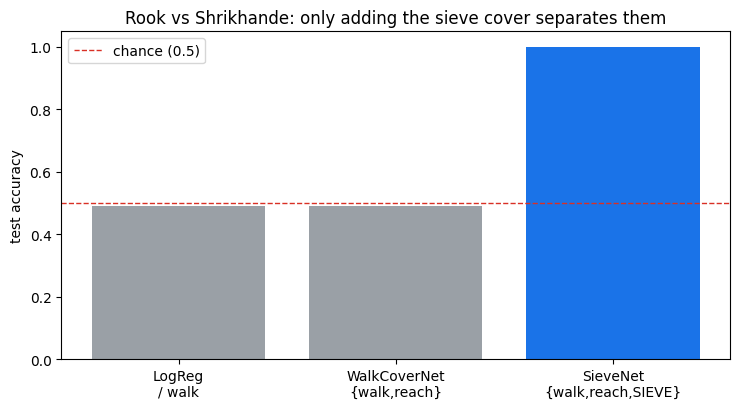

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
names = ["LogReg\n/ walk", "WalkCoverNet\n{walk,reach}", "SieveNet\n{walk,reach,SIEVE}"]
vals = [acc_lr, acc_walk, acc_sieve]
ax.bar(range(3), vals, color=["#9aa0a6", "#9aa0a6", "#1a73e8"])
ax.axhline(0.5, ls="--", lw=1, color="#d93025", label="chance (0.5)")
ax.set_xticks(range(3)); ax.set_xticklabels(names)
ax.set_ylabel("test accuracy"); ax.set_ylim(0, 1.05); ax.legend()
ax.set_title("Rook vs Shrikhande: only adding the sieve cover separates them")
plt.tight_layout(); plt.show()

## 3.4 · Takeaway

Walk/reachability covers and the trivial baseline sit at chance; the same
architecture with the sieve cover added reaches 100%. The separation comes
entirely from putting the sieve cover in the basis, the Grothendieck thesis
("design message passing by choosing covers") made load-bearing on a pair that
defeats WL. This mirrors, at toy scale, the paper's zero-failure results on the
SRG / CSL / BREC isomorphism benchmarks.

Notebook 04 pushes further: a setting where collapsing time destroys the
signal, and the sieve closure becomes the literal causal past of an event.